In [44]:
# import openkarst
import pykasso as pk
import importlib
importlib.reload(pk)
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import networkx as nx
import openkarst.models
importlib.reload(openkarst.models)
import openkarst.io.cave_data_loader as cdl
importlib.reload(cdl)
import seaborn as sns
import openpnm as op
import contextily as cx
import geopandas as gpd
import pickle
from openkarst.network_generation import compute_conduit_lengths
from openkarst.visualization.animation_pyvista import animate_network
from openkarst.models import FlowSimulation
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../src"))) #use this to be able to import local packages


In [2]:
import utils.config as config
importlib.reload(config)
from utils.utils import *
from utils.config import * 
from utils.calibration import *
from utils.conduits import *
from utils.geos import *

In [4]:
def get_outlet_Q(Q, outflow_node_ids, edges):
    outlets ={}
    for node in outflow_node_ids:
        edges_loc = edges[(edges.to_id == node) | (edges.from_id == node)].index
        outlet_Q = 0
        for edge in edges_loc:
            outlet_Q += Q[:, edge]
        outlets[node] = outlet_Q
    return outlets

<Axes: xlabel='datetime', ylabel='m3/d'>

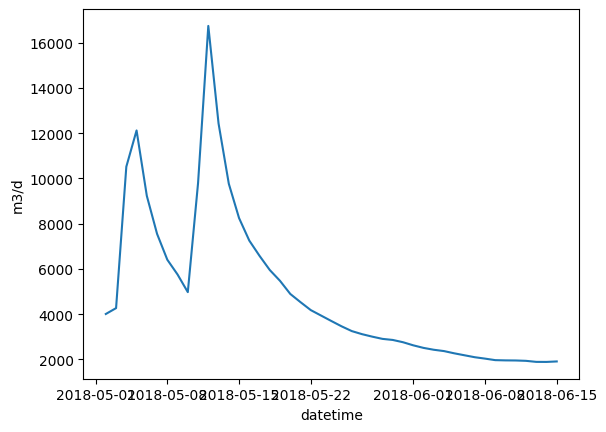

In [ ]:
actual_Q = pd.read_csv('../../data/discharge/calibration_discharge_2018.csv')
actual_Q = convert_df_to_datetime(actual_Q, 'datetime')
time_start = '2018-05-02'
time_end = '2018-06-15'


In [ ]:
#compare different recharge conditions
results_10 = np.load('all_inlets_single_peak/results_arrays.npz')
Q_10 = results_10['Q']
y_10 = results_10['y']
in_10 = pickle.load(open('all_inlets_single_peak/input_data.pkl', 'rb'))
nodes = in_10['nodes']
edges = in_10['edges']
outlets = in_10['outlets']
inlets = in_10['inlets']
t_10 = pd.to_datetime(time_start) + pd.to_timedelta(results_10['t'], unit='s')
outlet_Q_10 = get_outlet_Q(Q_10, outlets, edges)


TypeError: unsupported operand type(s) for *: 'int' and 'dict'

In [23]:
results_1 = np.load('1_inlet_single_peak/results_arrays.npz')
Q_1 = results_1['Q']
y_1 = results_1['y']
in_1 = pickle.load(open('1_inlet_single_peak/input_data.pkl', 'rb'))
nodes = in_1['nodes']
edges = in_1['edges']
outlets = in_1['outlets']
inlets = in_1['inlets']
t_1 = pd.to_datetime(time_start) + pd.to_timedelta(results_1['t'], unit='s')
outlet_Q_1 = get_outlet_Q(Q_1, outlets, edges)

In [50]:
results5 = np.load('5_inlets_single_peak/results_arrays.npz')
Q5 = results5['Q']
y5 = results5['y']
in5 = pickle.load(open('5_inlets_single_peak/input_data.pkl', 'rb'))
nodes = in5['nodes']
edges = in5['edges']
outlets = in5['outlets']
inlets = in5['inlets']
t5 = pd.to_datetime(time_start) + pd.to_timedelta(results5['t'], unit='s')
outlet_Q5 = get_outlet_Q(Q5, outlets, edges)

In [85]:
results5_1 = np.load('5_inlets_single_peak_1/results_arrays.npz')
Q5_1 = results5_1['Q']
y5_1 = results5_1['y']
in5_1 = pickle.load(open('5_inlets_single_peak_1/input_data.pkl', 'rb'))
nodes_1 = in5_1['nodes']
edges_1 = in5_1['edges']
outlets_1 = in5_1['outlets']
inlets_1 = in5_1['inlets']
t5_1 = pd.to_datetime(time_start) + pd.to_timedelta(results5_1['t'], unit='s')
outlet_Q5_1 = get_outlet_Q(Q5_1, outlets_1, edges_1)

In [81]:
recharge = np.array(in5['inflow_boundary'][tuple(inlets)]['flow']) * len(inlets) * 86400  #convert to m3/day
rech_t = pd.to_datetime(time_start) + pd.to_timedelta(in5['inflow_boundary'][tuple(inlets)]['time'], unit = 's')

<Axes: xlabel='datetime', ylabel='m3/d'>

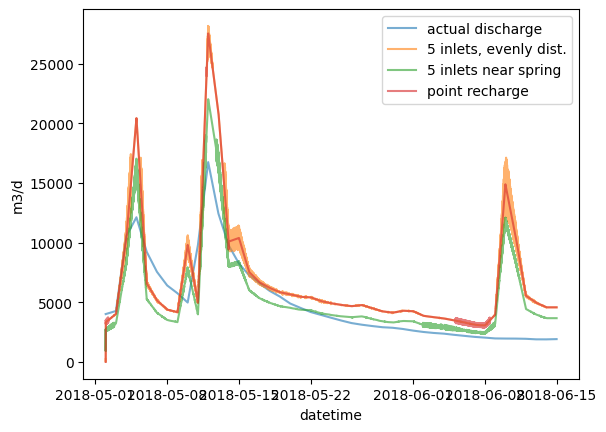

In [87]:
sns.lineplot(actual_Q[(actual_Q['datetime'] >= time_start) & (actual_Q['datetime'] <= time_end)], x = 'datetime', y = 'm3/d', label = 'actual discharge', alpha = 0.6)
sns.lineplot(y = outlet_Q5_1[0]*-86400, x = t5_1, label = '5 inlets, evenly dist.', alpha = 0.6)
sns.lineplot(y = outlet_Q5[0]*-86400, x = t5, label = '5 inlets near spring', alpha = 0.6)
sns.lineplot(y = outlet_Q_1[0]*-86400, x = t_1, label = 'point recharge', alpha = 0.6)



Text(0.5, 1.0, 'Differing recharge distribution')

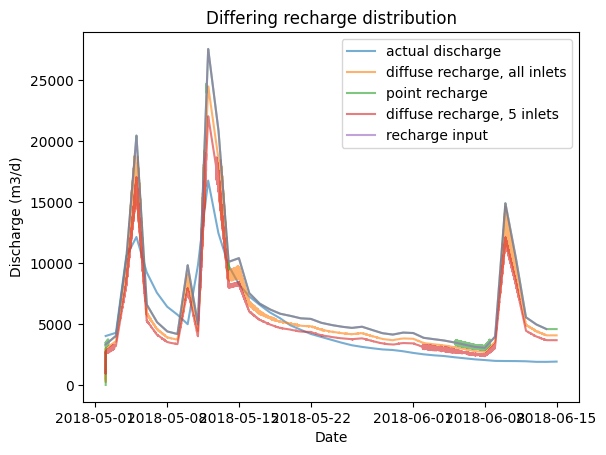

In [84]:
sns.lineplot(actual_Q[(actual_Q['datetime'] >= time_start) & (actual_Q['datetime'] <= time_end)], x = 'datetime', y = 'm3/d', label = 'actual discharge', alpha = 0.6)
sns.lineplot(y = outlet_Q_10[0]*-86400, x = t_10, label = 'diffuse recharge, all inlets', alpha = 0.6)
sns.lineplot(y = outlet_Q_1[0]*-86400, x = t_1, label = 'point recharge', alpha = 0.6)
sns.lineplot(y = outlet_Q5[0]*-86400, x = t5, label = 'diffuse recharge, 5 inlets', alpha = 0.6)
sns.lineplot(y = recharge, x = rech_t, label = 'recharge input', alpha = 0.6)

plt.ylabel('Discharge (m3/d)')
plt.xlabel('Date')
plt.title("Differing recharge distribution")

In [54]:
edges['y_0'] = nodes.iloc[edges.from_id].reset_index().y
edges['y_1'] = nodes.iloc[edges.to_id].reset_index().y
edges['x_0'] = nodes.iloc[edges.from_id].reset_index().x
edges['x_1'] = nodes.iloc[edges.to_id].reset_index().x

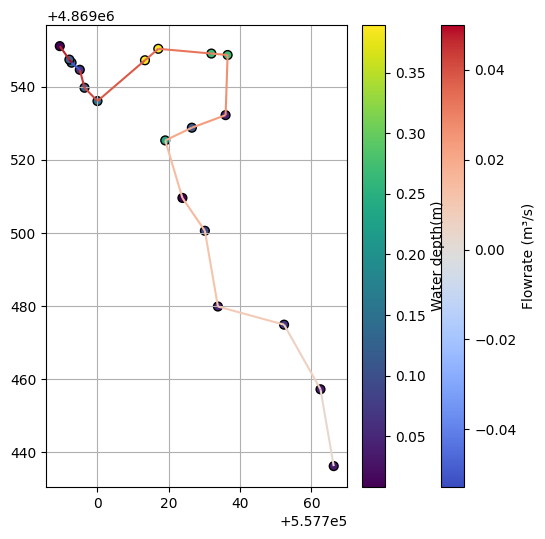

In [38]:
from matplotlib.collections import LineCollection
segments = edges[['x_0', 'y_0', 'x_1', 'y_1']].values.reshape(-1, 2, 2)
Q = Q_10
y = y_10
ts = len(Q)-1
# ts = 10
norm = plt.Normalize(vmin=Q[ts].min(), vmax=Q[ts].max())

# Get seaborn colormap
palette = sns.color_palette("coolwarm", as_cmap=True)

lc = LineCollection(segments, cmap=palette, norm=norm)
lc.set_array(Q[ts] * -1)

palette_y = sns.color_palette("viridis", as_cmap=True)
norm_y = plt.Normalize(vmin=min(y[ts]), vmax=max(y[ts]))

fig, ax = plt.subplots(figsize=(6, 6))
ax.add_collection(lc)
ax.autoscale()  # Needed for LineCollection to be visible
sc = ax.scatter(nodes['x'], nodes['y'], c=y[ts], cmap=palette_y, norm=norm_y, edgecolor='k', s=40)
plt.colorbar(lc, ax=ax, label="Flowrate (m³/s)")
cbar_y = plt.colorbar(sc, ax=ax, label="Water depth(m)", location="right", pad=0.04)

plt.grid(True)
# plt.title(rf"Steady state flow distibution, $Q_{{in}}$ = {Q_in}")

# plt.title(f"Steady state flow distibution, t = {np.round(t[ts], 3)}")
# plt.ylim(4.869530e6)


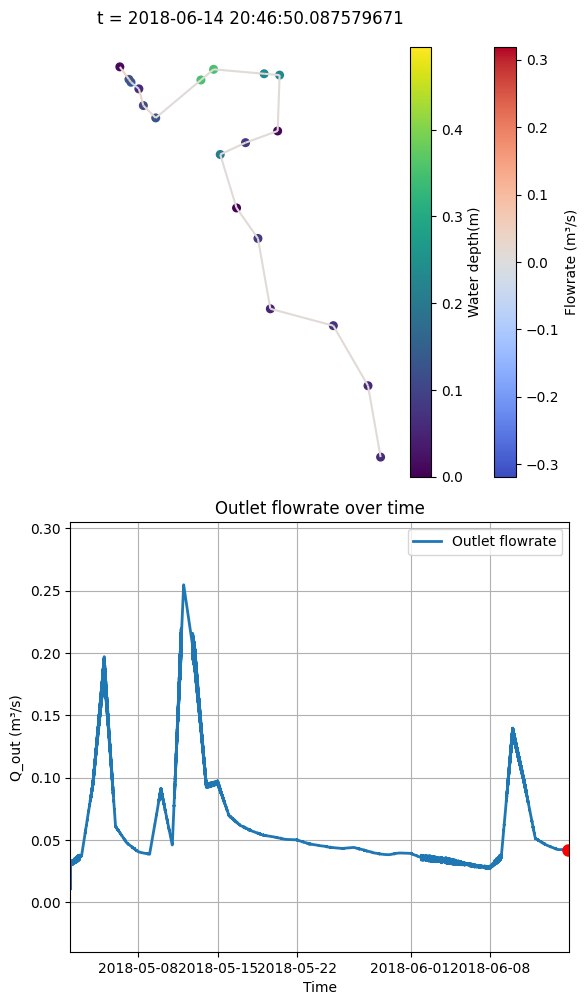

In [55]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.animation import FuncAnimation
import seaborn as sns
import numpy as np

# Suppose you already have:
# edges: DataFrame with ['x_0', 'y_0', 'x_1', 'y_1']
# nodes: DataFrame with ['x', 'y']
# Q: array of shape (nt, n_edges)
# y: array of shape (nt, n_nodes)
# t: array of times (optional)
Q = Q5
y = y5
t = t5
Q_out = -1 * outlet_Q5[0]
path = '5_inlets.gif'

segments = edges[['x_0', 'y_0', 'x_1', 'y_1']].values.reshape(-1, 2, 2)
dt = 1000
nt = len(Q) //dt # number of t

# Colormaps and normalization
flow_cmap = sns.color_palette("coolwarm", as_cmap=True)
node_cmap = sns.color_palette("viridis", as_cmap=True)
norm_y = plt.Normalize(vmin=y.min(), vmax=y.max())

vmin_q, vmax_q = Q.min(), Q.max()
vmin_y, vmax_y = y.min(), y.max()
norm_q = plt.Normalize(vmin=vmin_q, vmax=vmax_q)

# --- Set up figure ---
fig, ax = plt.subplots(2, 1, figsize=(6, 10))
ax[0].set_aspect('equal')
ax[0].set_axis_off()

# Initialize LineCollection and scatter
lc = LineCollection(segments, cmap=flow_cmap, norm=norm_q)
lc.set_array(Q[0] * -1)
edge_plot = ax[0].add_collection(lc)

sc = ax[0].scatter(nodes['x'], nodes['y'], c=y[0], cmap=node_cmap, norm=norm_y, s=30)

# Colorbar for edges
cbar = plt.colorbar(edge_plot, ax=ax[0], label="Flowrate (m³/s)")
cbar.set_label("Flowrate (m³/s)")
cbar_y = plt.colorbar(sc, ax=ax[0], label="Water depth(m)", location="right", pad=0.04)

ax[0].set_title(f"t = 0")

line, = ax[1].plot(t, Q_out, color="tab:blue", lw=2, label="Outlet flowrate")
dot, = ax[1].plot([], [], 'ro', markersize=8)
ax[1].set_xlim(t[0], t[-1])
ax[1].set_ylim(Q_out.min() - 0.05, Q_out.max() + 0.05)
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Q_out (m³/s)")
ax[1].set_title("Outlet flowrate over time")
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
# --- Animation update function ---
def update(frame):
    lc.set_array(Q[frame*dt] * -1)
    sc.set_array(y[frame*dt])
    ax[0].set_title(f"t = {t[frame*dt]}")
    dot.set_data([t[frame*dt]], [Q_out[frame*dt]])

    return lc, sc

# --- Create animation ---
ani = FuncAnimation(
    fig, update, frames=nt, interval=200, blit=False, repeat=True
)

# --- Save to GIF or MP4 ---
ani.save(path, writer='pillow', fps=15)
# or: ani.save("graph_evolution.mp4", writer='ffmpeg', fps=5)

plt.show()